In [2]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt

In [31]:
from sim_class import PhotonicGlassMCSimulator

sim = PhotonicGlassMCSimulator(
    film_thickness = 77.0, #um
    phi = 0.56, 
    fine_roughness=0.5,
    coarse_roughness=0.9,
    r_i=0.138, 
    n_m=1.0, 
    k_p=2e-5, 
    pdi=0.03, 
    detect_angle=90
    )


In [4]:
wvl = 0.55 # um
wvl_array = np.linspace(0.400, 0.800, 1000)
theta_array = np.linspace(1e-4, np.pi, 1000)    # radians
theta_deg = np.degrees(theta_array)             # degrees  

### Step 3: effective index, absorption coefficient 확인

In [18]:
n_p = sim.get_n_p_real_sellmeier(wvl) + 1j * sim.k_p
n_eff = sim._get_n_eff_ps_matrix(wvl)
mu_a = sim._get_mu_a(wvl, n_eff)

print("n_p                      =", n_p)
print("n_eff                    =", n_eff)
print("mu_a [1/um]              =", mu_a)
print("absorption length [um]   =", np.inf if mu_a == 0 else 1 / mu_a)

n_p                      = (1.5958939298996344+2e-05j)
n_eff                    = (1.3238414651006658+1.0657361486477478e-05j)
mu_a [1/um]              = 0.00024349882583686138
absorption length [um]   = 4106.795983771918


/home/shinbo/miniconda3/envs/meep/lib/python3.13/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/shinbo/miniconda3/envs/meep/lib/python3.13/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


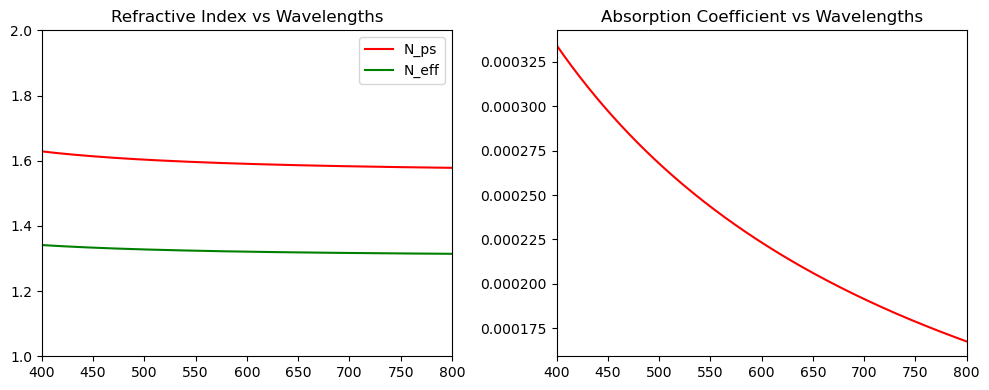

In [20]:
n_p_array = sim.get_n_p_real_sellmeier(wvl_array) + 1j * sim.k_p
n_eff_array = [sim._get_n_eff_ps_matrix(wvl) for wvl in wvl_array]
mu_a_array = [sim._get_mu_a(wvl, sim._get_n_eff_ps_matrix(wvl)) for wvl in wvl_array] 
x = wvl_array * 1000


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.plot(x, n_p_array, color='red', label='N_ps')
ax1.plot(x, np.real(n_eff_array), color='green', label='N_eff')
ax1.set_title("Refractive Index vs Wavelengths")
ax1.legend()
ax1.set_ylim(1, 2)
ax1.set_xlim(400, 800)

ax2.plot(x, mu_a_array, color='red', label='mu_a')
ax2.set_title("Absorption Coefficient vs Wavelengths")
ax2.set_xlim(400, 800)

plt.tight_layout()
plt.show()

### Step 4: Schulz distribution 확인

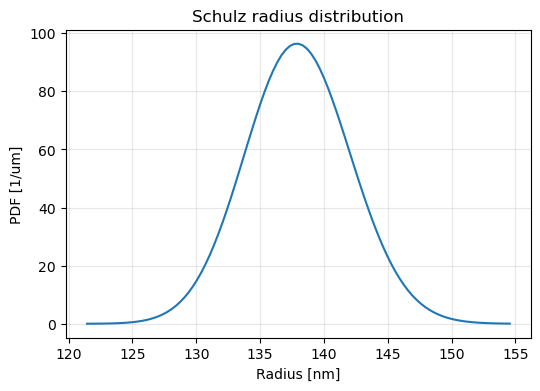

mean radius [um] ≈ 0.13799927363919218
normalization = 1.0


In [6]:
radius_samples, size_pdf = sim._get_schulz_distribution(
    n_points=101,
    n_std=4.0,
)

plt.figure(figsize=(6, 4))
plt.plot(radius_samples * 1000, size_pdf)
plt.xlabel("Radius [nm]")
plt.ylabel("PDF [1/um]")
plt.title("Schulz radius distribution")
plt.grid(True, alpha=0.3)
plt.show()

print("mean radius [um] ≈", np.trapezoid(radius_samples * size_pdf, radius_samples))
print("normalization =", np.trapezoid(size_pdf, radius_samples))

### Step 5: structure factor 확인

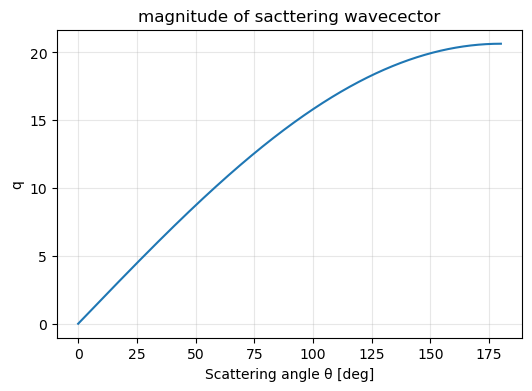

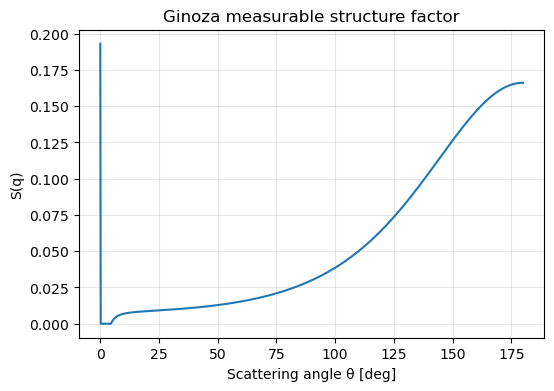

In [42]:
q = sim.get_q(np.real(n_eff), theta_array, wvl)
S_q = sim._get_structure_factor_ginoza(q)

plt.figure(figsize=(6, 4))
plt.plot(theta_deg, q)
plt.xlabel("Scattering angle θ [deg]")
plt.ylabel("q")
plt.title("magnitude of sacttering wavecector")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(theta_deg, S_q)
plt.xlabel("Scattering angle θ [deg]")
plt.ylabel("S(q)")
plt.title("Ginoza measurable structure factor")
plt.grid(True, alpha=0.3)
plt.show()

q_peak [1/um] = 26.242400640325066
theta_peak at 550 nm [deg] = 120.36225874905095


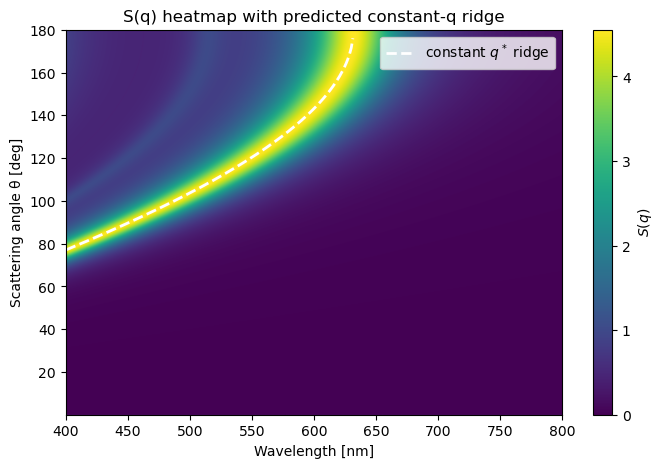

In [43]:
S_map = np.zeros((len(theta_array), len(wvl_array)))
S_max = np.zeros(len(theta_array))
S_min = np.zeros(len(theta_array))

for j, wvl in enumerate(wvl_array):
    n_eff = sim._get_n_eff_ps_matrix(wvl)
    q = sim.get_q(np.real(n_eff), theta_array, wvl)
    S_q = sim._get_structure_factor_ginoza(q)
    S_map[:, j] = S_q
    
    S_max[j] = np.max(S_q)
    S_min[j] = np.min(S_q)

# 1) 기준 파장에서 S(q)의 peak q* 찾기
wvl0 = 0.55  # um
n_eff0 = sim._get_n_eff_ps_matrix(wvl0)
q0 = sim.get_q(np.real(n_eff0), theta_array, wvl0)
S0 = sim._get_structure_factor_ginoza(q0)

idx_peak = np.argmax(S0)
q_peak = q0[idx_peak]
theta_peak_deg = np.degrees(theta_array[idx_peak])

print("q_peak [1/um] =", q_peak)
print("theta_peak at 550 nm [deg] =", theta_peak_deg)

# 2) 각 wavelength에서 q_peak에 해당하는 theta 예측
wvls = np.linspace(0.400, 0.800, 300)
theta_ridge = []

for wvl in wvls:
    n_eff = sim._get_n_eff_ps_matrix(wvl)
    arg = q_peak * wvl / (4.0 * np.pi * np.real(n_eff))
    
    if arg <= 1.0:
        theta_ridge.append(2.0 * np.arcsin(arg))
    else:
        theta_ridge.append(np.nan)

theta_ridge = np.array(theta_ridge)

# 3) heatmap 위에 overlay
plt.figure(figsize=(8, 5))
plt.imshow(
    S_map,
    extent=[wvls[0]*1000, wvls[-1]*1000, theta_deg[0], theta_deg[-1]],
    aspect="auto",
    origin="lower"
)
plt.colorbar(label=r"$S(q)$")
plt.plot(wvls * 1000, np.degrees(theta_ridge), "w--", linewidth=2, label=r"constant $q^*$ ridge")
plt.xlabel("Wavelength [nm]")
plt.ylabel("Scattering angle θ [deg]")
plt.title("S(q) heatmap with predicted constant-q ridge")
plt.legend()
plt.show()

각 파장에서 생성되는 Structure의 최댓값과 최솟값

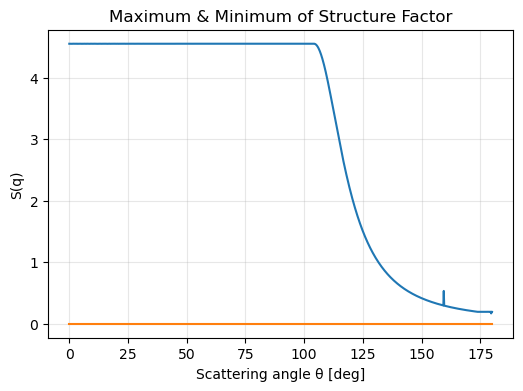

In [44]:
plt.figure(figsize=(6, 4))
plt.plot(theta_deg, S_max, label="S(q) max")
plt.plot(theta_deg, S_min, label="S(q) min")
plt.xlabel("Scattering angle θ [deg]")
plt.ylabel("S(q)")
plt.title("Maximum & Minimum of Structure Factor")
plt.grid(True, alpha=0.3)
plt.show()

### Step 6: Mie differential cross section 확인

`csca_mie`는 구조 인자를 곱하지 않은 단일입자 산란 단면적:
$C_{sca}^{Mie} = 2π∫\frac{dC_{sca}^{Mie}}{dΩ}sinθdθ$

csca_sample은 구조 인자까지 포함한 sample effective scattering cross section:
$C_{sca}^{sample} = 2π∫\frac{dC_{sca}^{Mie}}{dΩ}S(q)sinθdθ$

Monte Carlo의 bulk step size에는 csca_sample이 들어가야 해. SI에서 scattering length를
$l_{sca}= \frac{1}{ρC_{sca}^{sample}}$



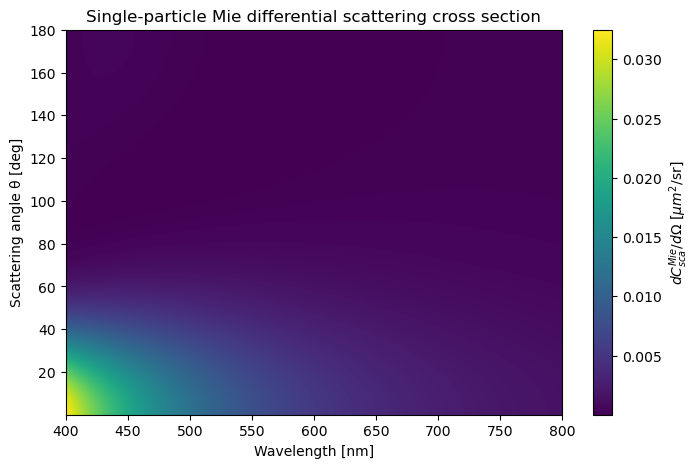

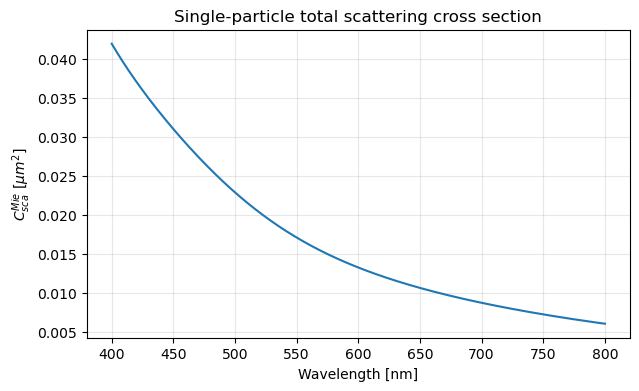

In [41]:
mie_map = np.zeros((len(theta_array), len(wvl_array)))
csca_mie_list = []

for j, wvl in enumerate(wvl_array):
    n_p_complex = sim.get_n_p_real_sellmeier(wvl) +  1j * sim.k_p
    n_eff_complex = sim._get_n_eff_ps_matrix(wvl)
    
    diff_mie, csca_mie, _, _ = sim._get_mie_absorbing(
        wavelength=wvl,
        n_p_complex=n_p_complex,
        n_eff_complex=n_eff_complex,
        theta_array=theta_array,
        backend="internal",
    )
    
    mie_map[:, j] = diff_mie
    csca_mie_list.append(csca_mie)

csca_mie_list = np.asarray(csca_mie_list)

plt.figure(figsize=(8, 5))
plt.imshow(
    mie_map,
    extent=[wvls[0]*1000, wvls[-1]*1000, theta_deg[0], theta_deg[-1]],
    aspect="auto",
    origin="lower"
)
plt.colorbar(label=r"$dC_{sca}^{Mie}/d\Omega$ [$\mu m^2$/sr]")
plt.xlabel("Wavelength [nm]")
plt.ylabel("Scattering angle θ [deg]")
plt.title("Single-particle Mie differential scattering cross section")
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(wvl_array * 1000, csca_mie_list)
plt.xlabel("Wavelength [nm]")
plt.ylabel(r"$C_{sca}^{Mie}$ [$\mu m^2$]")
plt.title("Single-particle total scattering cross section")
plt.grid(True, alpha=0.3)
plt.show()

In [9]:
rho = 3 * sim.phi / (4*np.pi*sim.r_i**3)
geom = np.pi * sim.r_i**2

for wvl in [0.4, 0.5, 0.8]:
    n_eff = sim._get_n_eff_ps_matrix(wvl)
    n_p = sim.get_n_p_real_sellmeier(wvl) + 1j*sim.k_p

    phase, csca_sample, diff_sample = sim._get_phase_func_ginoza(
        wavelength=wvl,
        theta_array=theta_array,
        backend="internal",
    )

    diff_mie, csca_mie, _, _ = sim._get_mie_absorbing(
        wavelength=wvl,
        n_p_complex=n_p,
        n_eff_complex=n_eff,
        theta_array=theta_array,
        backend="internal",
    )

    print(f"\nλ={wvl*1000:.0f} nm")
    print("csca_mie     =", csca_mie, "Q_mie =", csca_mie/geom)
    print("csca_sample  =", csca_sample, "Q_sample =", csca_sample/geom)
    print("Weigthed S(q)=", csca_sample / csca_mie)
    print("l_scat_mie   =", 1/(rho*csca_mie))
    print("l_scat_sample=", 1/(rho*csca_sample))
    print("rho          =", rho)


λ=400 nm
csca_mie     = 0.07271633901053447 Q_mie = 1.2154132322067404
csca_sample  = 0.07472866064911579 Q_sample = 1.2490480710925835
Weigthed S(q)= 1.0276735829383516
l_scat_mie   = 0.27033721524889487
l_scat_sample= 0.26305747246702543
rho          = 50.870049297428714

λ=500 nm
csca_mie     = 0.03582230289117926 Q_mie = 0.5987499031785626
csca_sample  = 0.046475263577197404 Q_sample = 0.776808226192994
Weigthed S(q)= 1.2973834685720689
l_scat_mie   = 0.5487623911538908
l_scat_sample= 0.4229762475375701
rho          = 50.870049297428714

λ=800 nm
csca_mie     = 0.015046715698572105 Q_mie = 0.2514974985009632
csca_sample  = 0.0008663014348010568 Q_sample = 0.014479747485422124
Weigthed S(q)= 0.057574121300322474
l_scat_mie   = 1.3064600265603445
l_scat_sample= 22.691792719605555
rho          = 50.870049297428714


### Step 7: phase function / sample cross section 확인
### Step 8: CDF 확인

In [34]:
phase_map = np.zeros((len(theta_array), len(wvl_array)))
pdf_map = np.zeros((len(theta_array), len(wvl_array)))
cdf_map = np.zeros((len(theta_array), len(wvl_array)))
csca_sample_list = []
l_scat_list = []
l_star_list = []

for j, wvl in enumerate(wvl_array):
    n_p_complex = sim.get_n_p_real_sellmeier(wvl) +  1j * sim.k_p
    n_eff_complex = sim._get_n_eff_ps_matrix(wvl)
    
    phase_func, csca_sample, diff_sample = sim._get_phase_func_ginoza(
        wavelength=wvl,
        theta_array=theta_array,
        backend="internal",
    )
    cdf, theta_pdf = sim._cdf_phase(phase_func, theta_array)
    l_scat = sim._get_l_scat(csca_sample)
    l_star = sim._get_l_star(l_scat, theta_pdf, theta_array)
    
    cdf_map[:, j] = cdf
    pdf_map[:, j] = theta_pdf
    phase_map[:, j] = phase_func
    csca_sample_list.append(csca_sample)
    l_scat_list.append(l_scat)
    l_star_list.append(l_star)

csca_sample_list = np.asarray(csca_sample_list)
l_scat_list = np.asarray(l_scat_list)

#### Phase Function Heat Map

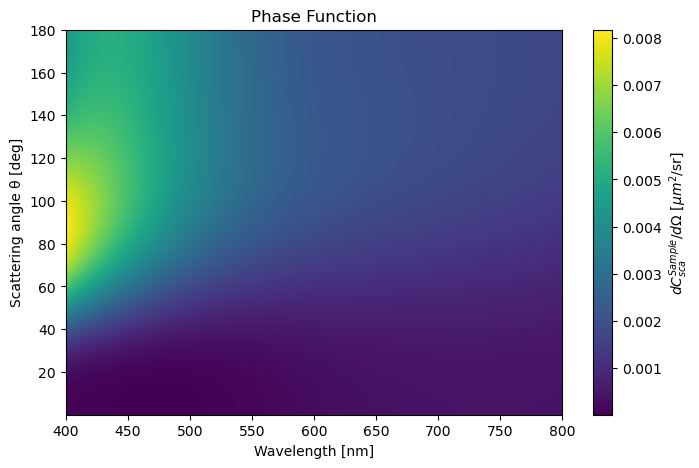

In [35]:
plt.figure(figsize=(8, 5))
plt.imshow(
    mie_map,
    extent=[wvls[0]*1000, wvls[-1]*1000, theta_deg[0], theta_deg[-1]],
    aspect="auto",
    origin="lower"
)
plt.colorbar(label=r"$dC_{sca}^{Sample}/d\Omega$ [$\mu m^2$/sr]")
plt.xlabel("Wavelength [nm]")
plt.ylabel("Scattering angle θ [deg]")
plt.title("Phase Function")
plt.show()

#### Single-particle total scattering cross section

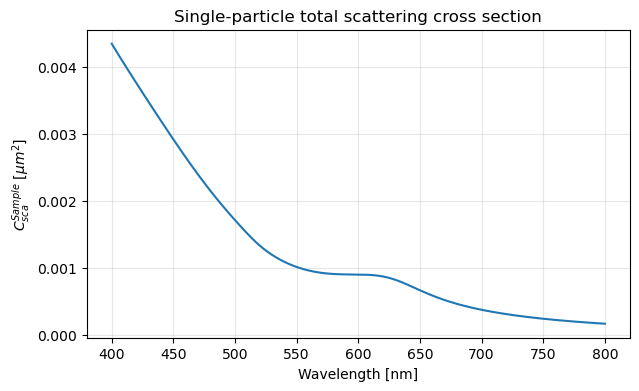

In [36]:
plt.figure(figsize=(7, 4))
plt.plot(wvl_array * 1000, csca_sample_list)
plt.xlabel("Wavelength [nm]")
plt.ylabel(r"$C_{sca}^{Sample}$ [$\mu m^2$]")
plt.title("Single-particle total scattering cross section")
plt.grid(True, alpha=0.3)
plt.show()

#### $l_{scat}$ & $l_{trans}$ by wavelength

논문에서는 transport length가 8 - 47um 범위에 존재한다고 말함

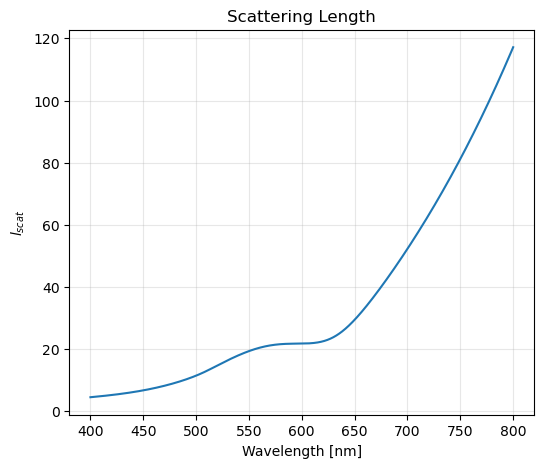

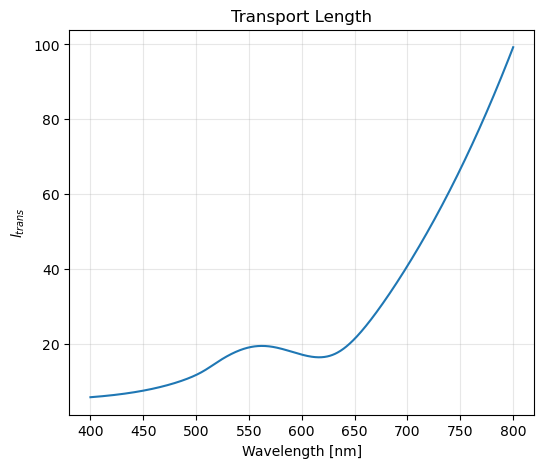

In [37]:
plt.figure(figsize=(6, 5))
plt.plot(wvl_array * 1000, l_scat_list)
plt.xlabel("Wavelength [nm]")
plt.ylabel(r"$l_{scat}$")
plt.title("Scattering Length")

plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(6, 5))
plt.plot(wvl_array * 1000, l_star_list)
plt.xlabel("Wavelength [nm]")
plt.ylabel(r"$l_{trans}$")
plt.title("Transport Length")
plt.grid(True, alpha=0.3)
plt.show()

$l_{trans} = \frac{l_{sca}}{1-<\cos >}$ 인데, $l_{trans}$이 너무 작기에, $l_{sca}$을 만드는 $C_{sca}^{sample}$을 조사한다

In [38]:
wvls = [0.4, 0.5, 0.8]

for wvl in wvls:
    n_p_complex= sim.get_n_p_real_sellmeier(wvl) + 1j * sim.k_p
    n_eff_complex = sim._get_n_eff_ps_matrix(wvl)


    diff, csca_int, S1, S2, a_n, b_n = sim._get_mie_absorbing(
        wavelength=wvl,
        n_p_complex=n_p_complex,
        n_eff_complex=n_eff_complex, 
        theta_array=theta_array, 
        backend="internal", 
        return_components=True    
    )

    k = 2.0 * np.pi * n_eff_complex / wvl
    n = np.arange(1, len(a_n) + 1)

    csca_series = (2.0 * np.pi / (np.real(k)**2)) * np.sum(
        (2*n + 1) * (np.abs(a_n)**2 + np.abs(b_n)**2)
    )

    print("csca by angular integration =", csca_int)
    print("csca by Mie coefficient sum  =", csca_series)
    print("ratio int / series =", csca_int / csca_series)

csca by angular integration = 0.04191323182631486
csca by Mie coefficient sum  = 0.04191662226474299
ratio int / series = 0.9999191147033099
csca by angular integration = 0.02289894204719225
csca by Mie coefficient sum  = 0.022900414982675813
ratio int / series = 0.9999356808387674
csca by angular integration = 0.006105823220698712
csca by Mie coefficient sum  = 0.0061060669754300955
ratio int / series = 0.999960079911936


In [39]:
wvl = 0.55
n_p_complex= sim.get_n_p_real_sellmeier(wvl) + 0j
n_eff_complex = complex(np.real(sim._get_n_eff_ps_matrix(wvl)), 0.0)


diff, csca_int, S1, S2, a_n, b_n = sim._get_mie_absorbing(
    wavelength=wvl,
    n_p_complex=n_p_complex,
    n_eff_complex=n_eff_complex, 
    theta_array=theta_array, 
    backend="internal", 
    return_components=True    
)
diff, csca_air, S1, S2, a_n, b_n = sim._get_mie_absorbing(
    wavelength=wvl,
    n_p_complex=n_p_complex,
    n_eff_complex=1.0 +0j, 
    theta_array=theta_array, 
    backend="internal", 
    return_components=True    
)

k = 2.0 * np.pi * n_eff_complex / wvl
n = np.arange(1, len(a_n) + 1)

csca_series = (2.0 * np.pi / (np.real(k)**2)) * np.sum(
    (2*n + 1) * (np.abs(a_n)**2 + np.abs(b_n)**2)
)

print("csca by angular integration =", csca_int)
print("csca by Mie coefficient sum  =", csca_series)
print("ratio int / series =", csca_int / csca_series)
print("csca in air medium =", csca_air)

csca by angular integration = 0.017130030134784667
csca by Mie coefficient sum  = 0.04467828400720716
ratio int / series = 0.38340841676062093
csca in air medium = 0.07830106857075543


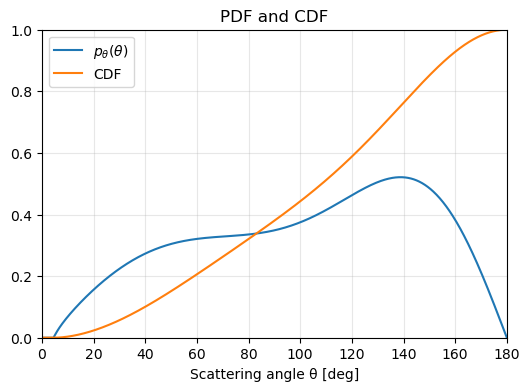

In [40]:
cdf, theta_pdf = sim._cdf_phase(phase_func, theta_array)

plt.figure(figsize=(6, 4))
plt.plot(theta_deg, theta_pdf, label=r"$p_\theta(\theta)$")
plt.plot(theta_deg, cdf, label="CDF")
plt.xlabel("Scattering angle θ [deg]")
plt.title("PDF and CDF")
plt.legend()
plt.ylim(0, 1.0)
plt.xlim(0, 180)
plt.grid(True, alpha=0.3)
plt.show()


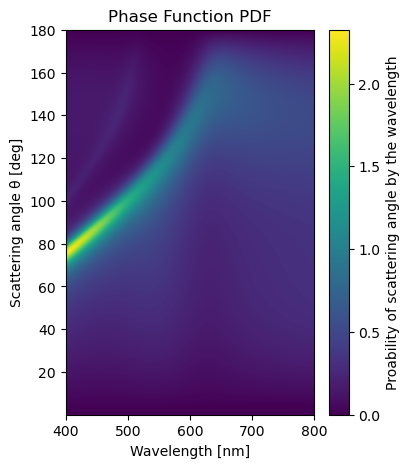

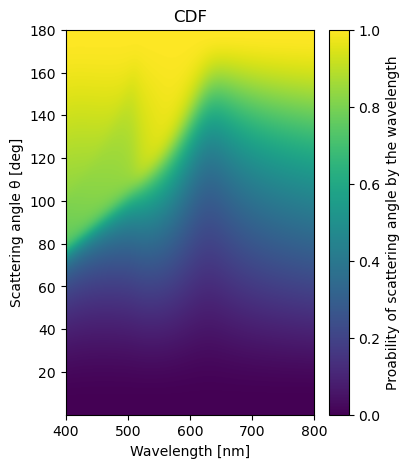

In [45]:
plt.figure(figsize=(4, 5))
plt.imshow(
    pdf_map,
    extent=[wvls[0]*1000, wvls[-1]*1000, theta_deg[0], theta_deg[-1]],
    aspect="auto",
    origin="lower"
)
plt.colorbar(label=r"Proability of scattering angle by the wavelength")
plt.xlabel("Wavelength [nm]")
plt.ylabel("Scattering angle θ [deg]")
plt.title("Phase Function PDF")
plt.show()

plt.figure(figsize=(4, 5))
plt.imshow(
    cdf_map,
    extent=[wvls[0]*1000, wvls[-1]*1000, theta_deg[0], theta_deg[-1]],
    aspect="auto",
    origin="lower"
)
plt.colorbar(label=r"Proability of scattering angle by the wavelength")
plt.xlabel("Wavelength [nm]")
plt.ylabel("Scattering angle θ [deg]")
plt.title("CDF")
plt.show()


### Step 9 : `_get_norm_vec` 검증

mean tilt angle [deg]: 35.991817148343294
RMS slope magnitude: 0.9025075684605908
target coarse roughness: 0.9


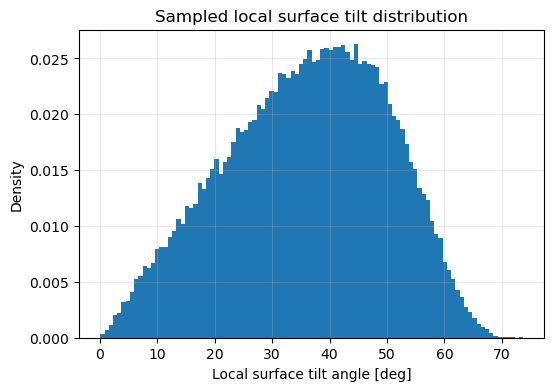

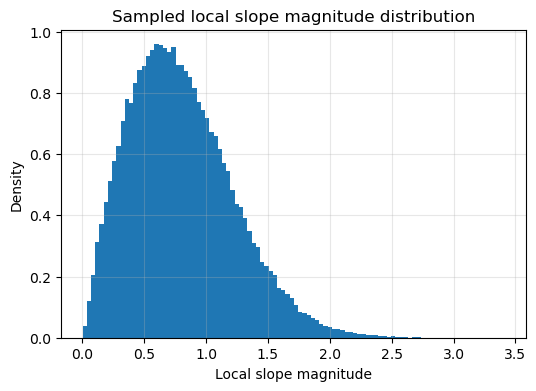

In [18]:
N = 100000
normals = np.array([sim._get_norm_vec(upward=True) for _ in range(N)])

tilt_angle = np.degrees(np.arccos(np.clip(normals[:, 2], -1, 1)))
slope_mag = np.sqrt((normals[:, 0] / normals[:, 2])**2 +
                    (normals[:, 1] / normals[:, 2])**2)

print("mean tilt angle [deg]:", tilt_angle.mean())
print("RMS slope magnitude:", np.sqrt(np.mean(slope_mag**2)))
print("target coarse roughness:", sim.coarse_roughness)

plt.figure(figsize=(6, 4))
plt.hist(tilt_angle, bins=100, density=True)
plt.xlabel("Local surface tilt angle [deg]")
plt.ylabel("Density")
plt.title("Sampled local surface tilt distribution")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(6, 4))
plt.hist(slope_mag, bins=100, density=True)
plt.xlabel("Local slope magnitude")
plt.ylabel("Density")
plt.title("Sampled local slope magnitude distribution")
plt.grid(True, alpha=0.3)
plt.show() 

reflected
R = 0.8989815139168686 T = 0.0 W = 0.8989815139168686
n_scat = 4 path = 553.3028813678003


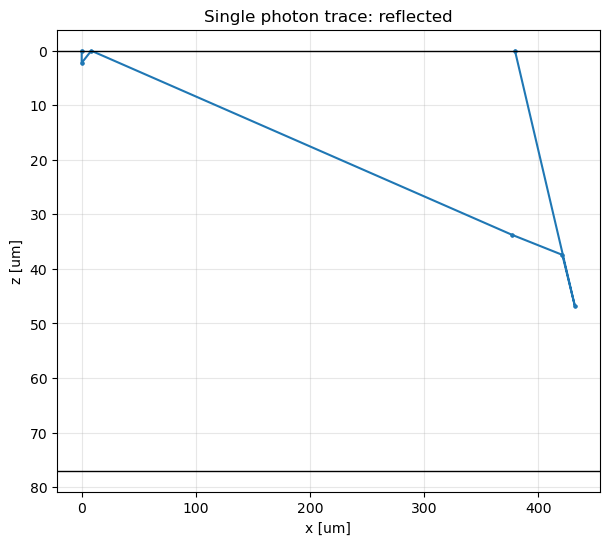

#0 event: start
#1 event: entered
#2 event: surface_step_move
#3 event: scatter
#4 event: hit_top
#5 event: internal_reflection
#6 event: bulk_step_move
#7 event: scatter
#8 event: bulk_step_move
#9 event: scatter
#10 event: bulk_step_move
#11 event: scatter
#12 event: hit_top
#13 event: exit_top_reflected


In [49]:
n_eff_complex = sim._get_n_eff_ps_matrix(wvl)
n_eff_real = np.real(n_eff_complex)
mu_a = sim._get_mu_a(wvl, n_eff_complex)

phase_norm, csca_sample, diff_sample = sim._get_phase_func_ginoza(
    wavelength=wvl,
    theta_array=theta_array,
    backend="internal",
)
cdf_norm, _ = sim._cdf_phase(phase_norm, theta_array)
l_scat_norm = sim._get_l_scat(csca_sample)

n_p_complex = sim.get_n_p_real_sellmeier(wvl) + 1j * sim.k_p
diff_mie, csca_mie, _, _ = sim._get_mie_absorbing(
    wavelength=wvl,
    n_p_complex=n_p_complex,
    n_eff_complex=n_eff_complex,
    theta_array=theta_array,
    backend="internal",
)
phase_surf = diff_mie / csca_mie
phase_surf /= 2*np.pi*np.trapezoid(phase_surf*np.sin(theta_array), theta_array)
cdf_surf, _ = sim._cdf_phase(phase_surf, theta_array)
l_scat_surf = sim._get_l_scat(csca_mie)

result = sim._track_single_photon(
    mu_a=mu_a,
    l_scat_norm=l_scat_norm,
    cdf_norm=cdf_norm,
    l_scat_surf=l_scat_surf,
    cdf_surf=cdf_surf,
    theta_array=theta_array,
    n_eff_real=n_eff_real,
    trace=True,
)

print(result["status"])
print("R =", result["R"], "T =", result["T"], "W =", result["W"])
print("n_scat =", result["n_scat"], "path =", result["path"])

trace = result["trace"]
xs = np.array([r[0] for r in trace])
zs = np.array([r[2] for r in trace])
events = [r[4] for r in trace]

plt.figure(figsize=(7, 6))
plt.plot(xs, zs, marker="o", markersize=2)
plt.axhline(0, color="k", linewidth=1)
plt.axhline(sim.film_thickness, color="k", linewidth=1)
plt.xlabel("x [um]")
plt.ylabel("z [um]")
plt.title(f"Single photon trace: {result['status']}")
plt.gca().invert_yaxis()  # optional: top surface visually at top
plt.grid(True, alpha=0.3)
plt.show()

for i, e in enumerate(events):
    print(f"#{i} event: {e}")

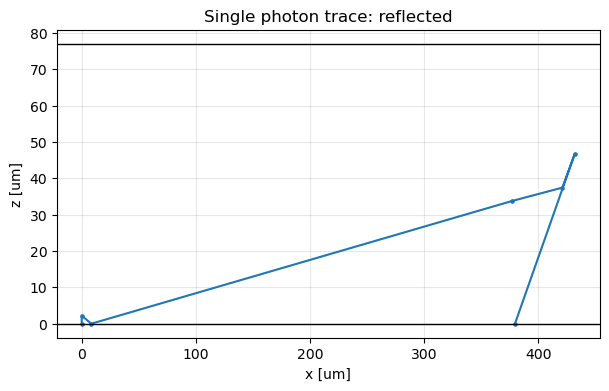

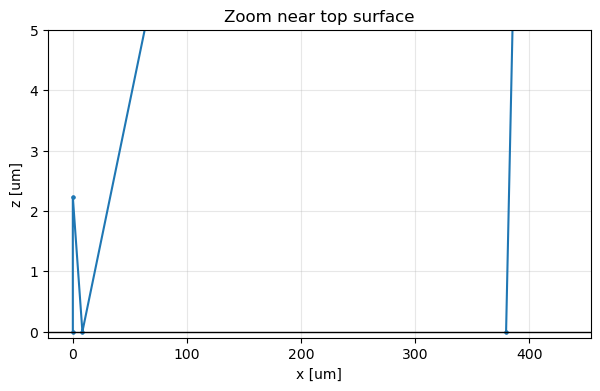

events: ['start', 'entered', 'surface_step_move', 'scatter', 'hit_top', 'internal_reflection', 'bulk_step_move', 'scatter', 'bulk_step_move', 'scatter', 'bulk_step_move', 'scatter', 'hit_top', 'exit_top_reflected']


In [50]:
trace = result["trace"]
xs = np.array([r[0] for r in trace])
zs = np.array([r[2] for r in trace])
events = [r[4] for r in trace]

plt.figure(figsize=(7, 4))
plt.plot(xs, zs, marker="o", markersize=2)
plt.axhline(0, color="k", linewidth=1)
plt.axhline(sim.film_thickness, color="k", linewidth=1)
plt.xlabel("x [um]")
plt.ylabel("z [um]")
plt.title(f"Single photon trace: {result['status']}")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(xs, zs, marker="o", markersize=2)
plt.axhline(0, color="k", linewidth=1)
plt.xlabel("x [um]")
plt.ylabel("z [um]")
plt.title("Zoom near top surface")
plt.ylim(-0.1, 5.0)
plt.grid(True, alpha=0.3)
plt.show()

print("events:", events[:30])

In [51]:
print("l_scat_norm =", l_scat_norm)
print("l_scat_surf =", l_scat_surf)
print("ratio surf/norm =", l_scat_surf / l_scat_norm)

l_scat_norm = 117.15149785873014
l_scat_surf = 3.219538443982814
ratio surf/norm = 0.027481837644663915


### 전 파장 시뮬레이션

MC Simulation:   0%|          | 0/1000 [00:00<?, ?it/s]

MC Simulation: 100%|██████████| 1000/1000 [07:32<00:00,  2.21it/s]


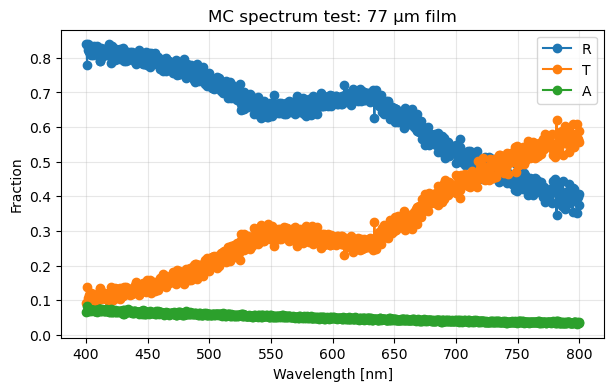

In [ ]:
theta_array = np.linspace(0.01, np.pi - 0.01, 700)
wvls_test = np.linspace(0.400, 0.800, 1000)

R, T, A, diags = sim.run_simulation(
    wvls=wvls_test,
    theta_array=theta_array,
    N_photons=1000,
    backend="internal",
    use_polydispersity=False,
    return_diagnostics=True,
)

plt.figure(figsize=(7, 4))
plt.plot(wvls_test * 1000, R, label="R")
plt.plot(wvls_test * 1000, T, label="T")
plt.plot(wvls_test * 1000, A, label="A")
plt.xlabel("Wavelength [nm]")
plt.ylabel("Fraction")
plt.title("MC spectrum test: 77 µm film")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

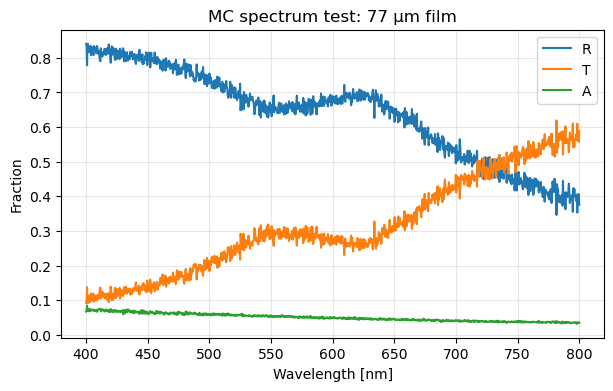

In [63]:
plt.figure(figsize=(7, 4))
plt.plot(wvls_test * 1000, R, label="R")
plt.plot(wvls_test * 1000, T, label="T")
plt.plot(wvls_test * 1000, A, label="A")
plt.xlabel("Wavelength [nm]")
plt.ylabel("Fraction")
plt.title("MC spectrum test: 77 µm film")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Debugging을 위한 로그 데이터

In [55]:
for d in diags:
    print(
        f"{d['wavelength']*1000:.0f} nm | "
        f"R={R[list(wvls_test).index(d['wavelength'])]:.3f}, "
        f"T={T[list(wvls_test).index(d['wavelength'])]:.3f}, "
        f"A={A[list(wvls_test).index(d['wavelength'])]:.3f} | "
        f"l_norm={d['l_scat_norm']:.3f}, "
        f"l_surf={d['l_scat_surf']:.3f}, "
        f"mu_a={d['mu_a']:.3e}, "
        f"mean_scat={d['mean_scatters']:.1f}, "
        f"status={d['status_count']}"
    )

400 nm | R=0.827, T=0.101, A=0.072 | l_norm=4.520, l_surf=0.469, mu_a=3.344e-04, mean_scat=54.2, status={'reflected': 875, 'transmitted': 125, 'absorbed': 0, 'max_events': 0}
402 nm | R=0.825, T=0.100, A=0.075 | l_norm=4.584, l_surf=0.475, mu_a=3.327e-04, mean_scat=56.0, status={'reflected': 873, 'transmitted': 127, 'absorbed': 0, 'max_events': 0}
404 nm | R=0.809, T=0.113, A=0.078 | l_norm=4.649, l_surf=0.481, mu_a=3.311e-04, mean_scat=58.3, status={'reflected': 855, 'transmitted': 145, 'absorbed': 0, 'max_events': 0}
406 nm | R=0.814, T=0.111, A=0.076 | l_norm=4.716, l_surf=0.487, mu_a=3.295e-04, mean_scat=56.2, status={'reflected': 862, 'transmitted': 138, 'absorbed': 0, 'max_events': 0}
408 nm | R=0.808, T=0.119, A=0.074 | l_norm=4.785, l_surf=0.493, mu_a=3.279e-04, mean_scat=53.4, status={'reflected': 852, 'transmitted': 148, 'absorbed': 0, 'max_events': 0}
410 nm | R=0.818, T=0.113, A=0.070 | l_norm=4.854, l_surf=0.500, mu_a=3.263e-04, mean_scat=49.7, status={'reflected': 860, 't

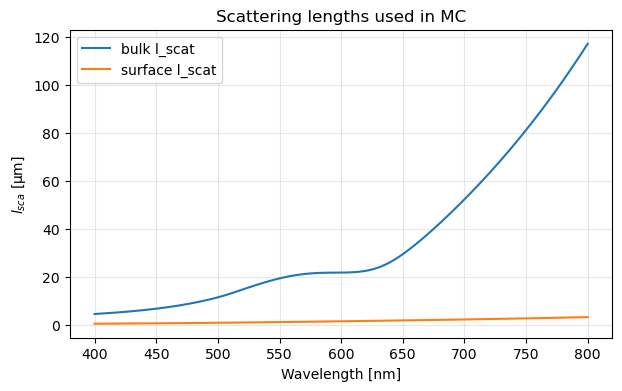

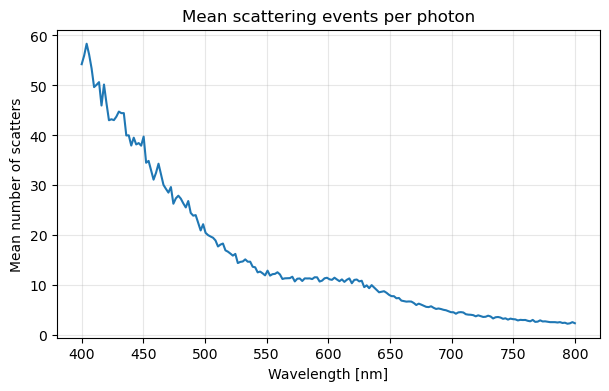

In [57]:
l_norm = np.array([d["l_scat_norm"] for d in diags])
l_surf = np.array([d["l_scat_surf"] for d in diags])
mu_a_arr = np.array([d["mu_a"] for d in diags])
mean_scat = np.array([d["mean_scatters"] for d in diags])

plt.figure(figsize=(7, 4))
plt.plot(wvls_test * 1000, l_norm, label="bulk l_scat")
plt.plot(wvls_test * 1000, l_surf, label="surface l_scat")
plt.xlabel("Wavelength [nm]")
plt.ylabel(r"$l_{sca}$ [µm]")
plt.title("Scattering lengths used in MC")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(wvls_test * 1000, mean_scat)
plt.xlabel("Wavelength [nm]")
plt.ylabel("Mean number of scatters")
plt.title("Mean scattering events per photon")
plt.grid(True, alpha=0.3)
plt.show()

In [58]:
print("min R,T,A:", R.min(), T.min(), A.min())
print("max R,T,A:", R.max(), T.max(), A.max())
print("max |R+T+A-1|:", np.max(np.abs(R + T + A - 1)))

min R,T,A: 0.38775195106305205 0.10001947793890466 0.03449964950138906
max R,T,A: 0.8280567037224699 0.5777483994355589 0.07811803888656096
max |R+T+A-1|: 1.1102230246251565e-16


In [59]:
for d in diags:
    max_events = d["status_count"].get("max_events", 0)
    if max_events > 0:
        print("max_events warning:", d["wavelength"], max_events)

In [3]:
filename = "mc_77um_test"

MC Simulation: 100%|██████████| 100/100 [41:42<00:00, 25.03s/it] 


mc_77um_test.npz is successfully saved!


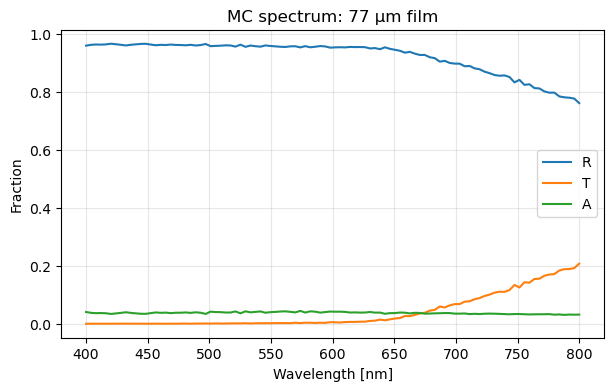

In [ ]:
wvls = np.linspace(0.400, 0.800, 100)



R, T, A, diags = sim.run_simulation(
    wvls=wvls,
    theta_array=theta_array,
    N_photons=5000,   # 먼저 5000 추천
    backend="internal",
    use_polydispersity=False,
    return_diagnostics=True,
    save_filename=filename
)

plt.figure(figsize=(7, 4))
plt.plot(wvls * 1000, R, label="R")
plt.plot(wvls * 1000, T, label="T")
plt.plot(wvls * 1000, A, label="A")
plt.xlabel("Wavelength [nm]")
plt.ylabel("Fraction")
plt.title("MC spectrum: 77 µm film")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Overlay data on the figure from the papaer

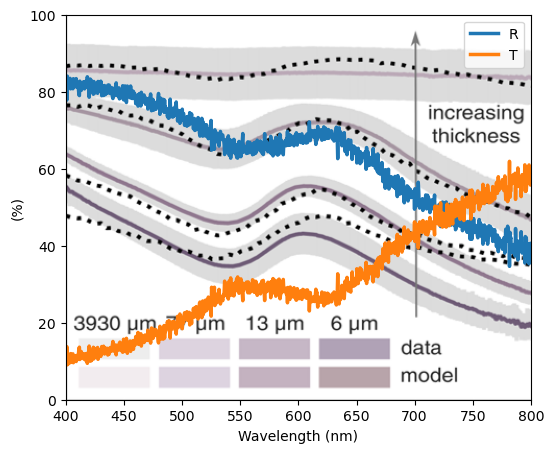

In [64]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

'''data = np.load(f"{filename}.npz")
R = data["reflectance"]
T = data["transmittance"]
A = data["absorbance"]
wvls = data["wavelengths"]'''

# Load Background Image
img = Image.open("figure3c.png")

fig, ax = plt.subplots(figsize=(6, 5))

# Put Reference Image at the background
ax.imshow(img, extent=[400, 800, 0, 100], aspect="auto")

# Overlay my graph
ax.plot(wvls_test*1000, R*100, linewidth=2.5, label="R")
ax.plot(wvls_test*1000, T*100, linewidth=2.5, label="T")
ax.set_xlim(400, 800)
ax.set_ylim(0, 100)
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("(%)")
ax.legend()
plt.show()

